# Week 6 Assessment

**Project 1:** Build a deep learning model that removes noise from images using a denoising autoencoder.
  


## Phase 1: Import Libraries and Set Configuration

In [12]:
import os
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1
NOISE_FACTOR = 0.45
BATCH_SIZE = 128
EPOCHS =15

print("TensorFlow version:", tf.__version__)
print("Setup completed successfully.")

TensorFlow version: 2.20.0
Setup completed successfully.


## Phase 2: Upload and Extract the Given Dataset

In [13]:
import os
from pathlib import Path

repo_path = Path("/content/MNIST-Autoecncoder")

if not repo_path.exists():
    !git clone https://github.com/NvsYashwanth/MNIST-Autoecncoder.git
else:
    print("GitHub repository already exists.")

print("Repository ready at:", repo_path)

GitHub repository already exists.
Repository ready at: /content/MNIST-Autoecncoder


## Phase 3: Load MNIST PNG Images from Folders

In [14]:
import torch
import numpy as np

train_pt_path = "/content/MNIST-Autoecncoder/data/MNIST/processed/training.pt"
test_pt_path = "/content/MNIST-Autoecncoder/data/MNIST/processed/test.pt"

train_data, train_labels = torch.load(train_pt_path, weights_only=False)
test_data, test_labels = torch.load(test_pt_path, weights_only=False)

# Convert images to NumPy and normalize
x_train = train_data.numpy().astype("float32") / 255.0
x_test = test_data.numpy().astype("float32") / 255.0

# Convert labels to NumPy
y_train = train_labels.numpy()
y_test = test_labels.numpy()

# Reshape images for CNN: (samples, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training images shape:", x_train.shape)
print("Testing images shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28, 1)
Testing images shape: (10000, 28, 28, 1)
Training labels shape: (60000,)
Testing labels shape: (10000,)


## Phase 4: Visualize Clean Sample Images

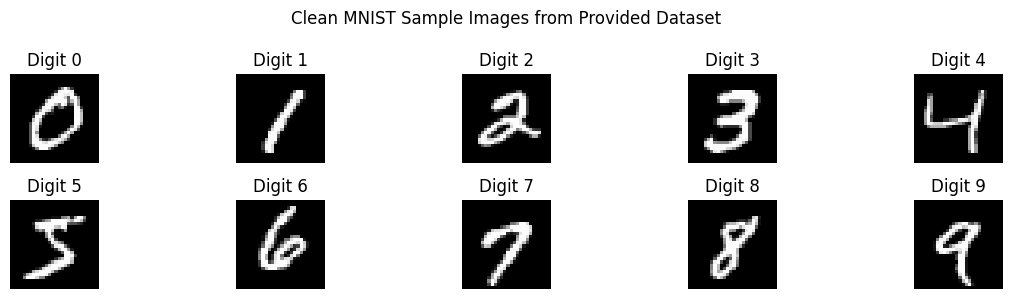

In [15]:
plt.figure(figsize=(12, 3))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx].squeeze(), cmap='gray')
    plt.title(f"Digit {i}")
    plt.axis('off')
plt.suptitle("Clean MNIST Sample Images from Provided Dataset")
plt.tight_layout()
plt.show()

## Phase 5: Add Artificial Noise.

In [16]:
def add_gaussian_noise(images, noise_factor=0.45):
    noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = images + noise
    noisy_images = np.clip(noisy_images, 0.0, 1.0)
    return noisy_images.astype(np.float32)

x_train_noisy = add_gaussian_noise(x_train, NOISE_FACTOR)
x_test_noisy = add_gaussian_noise(x_test, NOISE_FACTOR)

print("Noisy train shape:", x_train_noisy.shape)
print("Noisy test shape:", x_test_noisy.shape)
print("Noisy pixel range:", x_train_noisy.min(), "to", x_train_noisy.max())

Noisy train shape: (60000, 28, 28, 1)
Noisy test shape: (10000, 28, 28, 1)
Noisy pixel range: 0.0 to 1.0


## Phase 6: Visualize Original vs Noisy Images

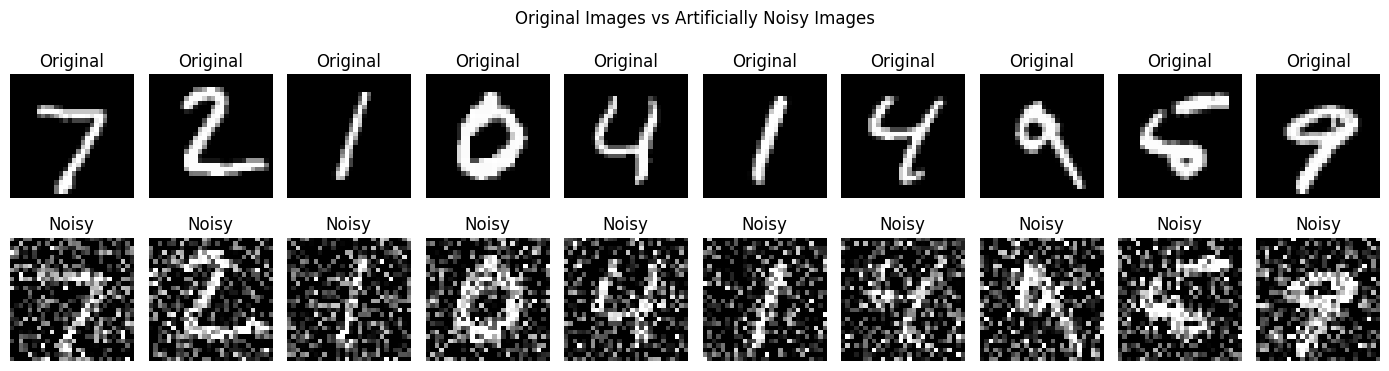

In [17]:
n = 10
plt.figure(figsize=(14, 4))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.suptitle("Original Images vs Artificially Noisy Images")
plt.tight_layout()
plt.show()

## Phase 7: Build the Denoising Autoencoder


In [18]:
def build_denoising_autoencoder():
    input_img = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), name='noisy_input')

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='encoder_conv1')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same', name='encoder_pool1')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='encoder_conv2')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same', name='bottleneck')(x)

    # Decoder
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='decoder_conv1')(encoded)
    x = layers.UpSampling2D((2, 2), name='decoder_upsample1')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='decoder_conv2')(x)
    x = layers.UpSampling2D((2, 2), name='decoder_upsample2')(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='clean_output')(x)

    return models.Model(input_img, decoded, name='MNIST_Denoising_Autoencoder')

autoencoder = build_denoising_autoencoder()
autoencoder.summary()

Model: "MNIST_Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv1 (Conv2D)          │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool1 (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv2 (Conv2D)          │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv1 (Conv2D)          │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample1               │ (None, 14, 14, 64)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv2 (Conv2D)          │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample2               │ (None, 28, 28, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clean_output (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Phase 8: Compile and Train the Model

- Input: noisy images  
- Target: original clean images  
- Loss: Binary Crossentropy  
- Optimizer: Adam

In [19]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['mse']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history = autoencoder.fit(
    x_train_noisy, x_train,
    validation_data=(x_test_noisy, x_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 187s 394ms/step - loss: 0.1444 - mse: 0.0265 - val_loss: 0.1034 - val_mse: 0.0135 - learning_rate: 0.0010
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 182s 388ms/step - loss: 0.1012 - mse: 0.0126 - val_loss: 0.0974 - val_mse: 0.0116 - learning_rate: 0.0010


## Phase 9: Plot Training and Validation Performance

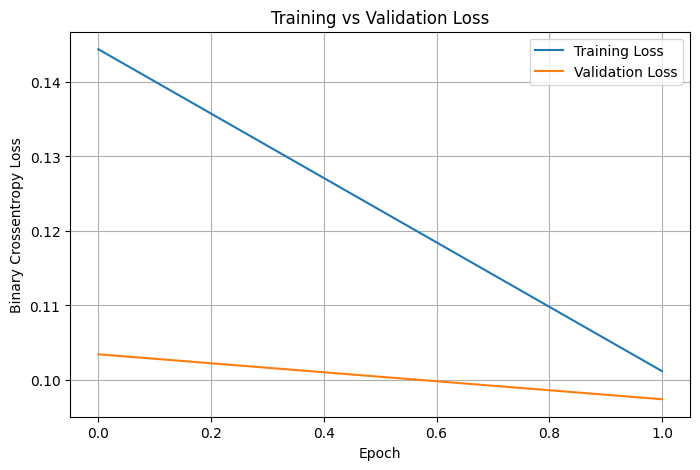

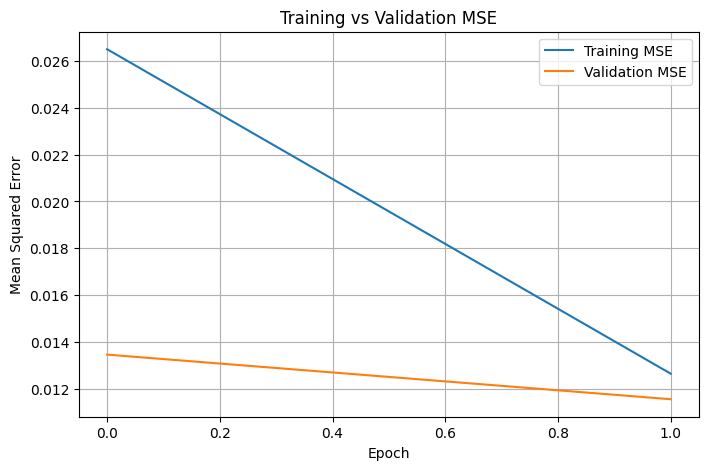

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Validation MSE')
plt.legend()
plt.grid(True)
plt.show()

## Phase 10: Generate Denoised Images on the Test Set

In [21]:
denoised_images = autoencoder.predict(x_test_noisy)
print("Denoised images shape:", denoised_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step
Denoised images shape: (10000, 28, 28, 1)


## Phase 11: Visualize Original, Noisy, and Reconstructed Images

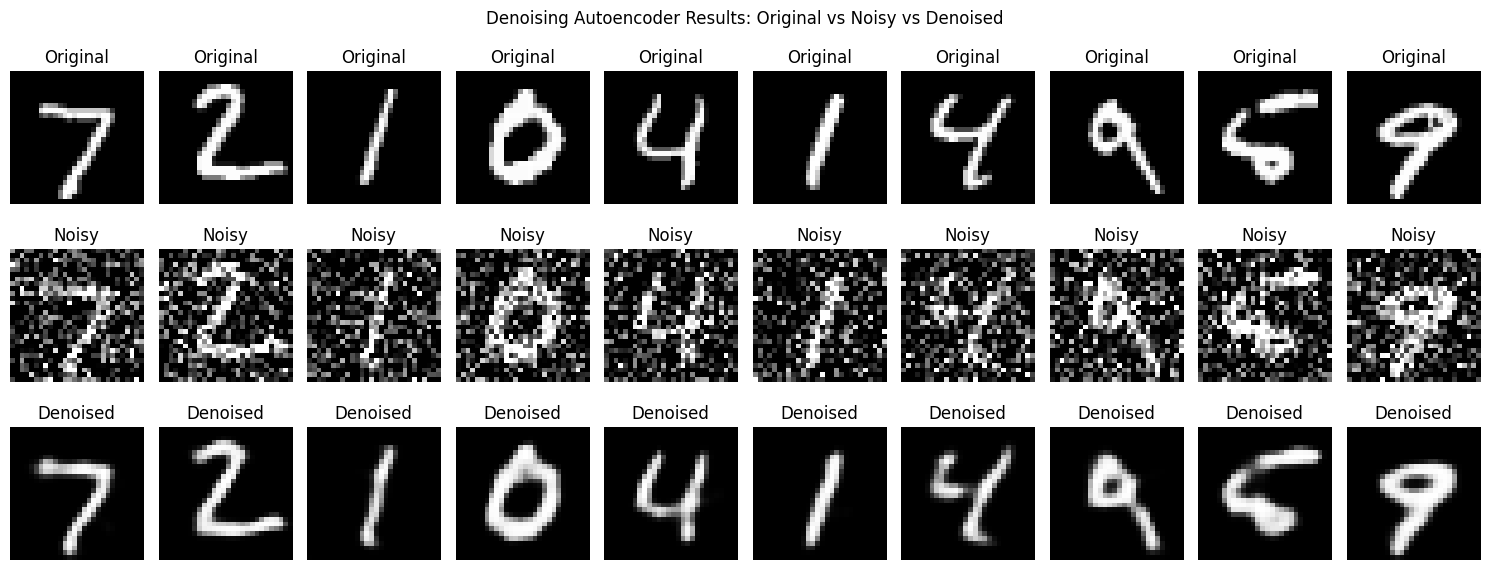

In [22]:
n = 10
plt.figure(figsize=(15, 6))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.suptitle("Denoising Autoencoder Results: Original vs Noisy vs Denoised")
plt.tight_layout()
plt.show()

## Phase 12: Evaluate Denoising Performance using MSE and PSNR

- **MSE:** Lower is better.  
- **PSNR:** Higher is better.

In [23]:
def calculate_mse(original, reconstructed):
    return np.mean((original - reconstructed) ** 2)


def calculate_psnr(original, reconstructed):
    mse = calculate_mse(original, reconstructed)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))

noisy_mse = calculate_mse(x_test, x_test_noisy)
denoised_mse = calculate_mse(x_test, denoised_images)
noisy_psnr = calculate_psnr(x_test, x_test_noisy)
denoised_psnr = calculate_psnr(x_test, denoised_images)

metrics_df = pd.DataFrame({
    'Image Type': ['Noisy Images', 'Denoised Images'],
    'MSE (Lower is Better)': [noisy_mse, denoised_mse],
    'PSNR (Higher is Better)': [noisy_psnr, denoised_psnr]
})
metrics_df

,Image Type,MSE (Lower is Better),PSNR (Higher is Better)
0,Noisy Images,0.097479,10.110879
1,Denoised Images,0.011551,19.373877


## Phase 13: Optional Innovation - Test Different Noise Levels

This shows how reconstruction performance changes as noise intensity increases.

In [24]:
noise_levels = [0.20, 0.35, 0.50, 0.65]
results = []
sample_count = 2000
x_eval = x_test[:sample_count]

for level in noise_levels:
    noisy_eval = add_gaussian_noise(x_eval, noise_factor=level)
    denoised_eval = autoencoder.predict(noisy_eval, verbose=0)
    results.append({
        'Noise Level': level,
        'Noisy MSE': calculate_mse(x_eval, noisy_eval),
        'Denoised MSE': calculate_mse(x_eval, denoised_eval),
        'Noisy PSNR': calculate_psnr(x_eval, noisy_eval),
        'Denoised PSNR': calculate_psnr(x_eval, denoised_eval)
    })

noise_results_df = pd.DataFrame(results)
noise_results_df

,Noise Level,Noisy MSE,Denoised MSE,Noisy PSNR,Denoised PSNR
0,0.20,0.021171,0.007222,16.742500,21.413429
1,0.35,0.062309,0.009208,12.054499,20.358303
2,0.50,0.115492,0.013590,9.374474,18.667931
3,0.65,0.166348,0.020924,7.789812,16.793507


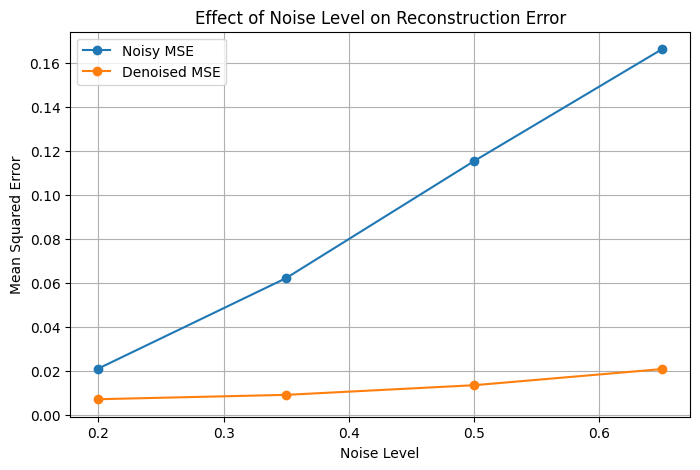

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(noise_results_df['Noise Level'], noise_results_df['Noisy MSE'], marker='o', label='Noisy MSE')
plt.plot(noise_results_df['Noise Level'], noise_results_df['Denoised MSE'], marker='o', label='Denoised MSE')
plt.xlabel('Noise Level')
plt.ylabel('Mean Squared Error')
plt.title('Effect of Noise Level on Reconstruction Error')
plt.legend()
plt.grid(True)
plt.show()

## Phase 14: Save the Trained Model

In [26]:
model_path = '/content/mnist_denoising_autoencoder.keras'
autoencoder.save(model_path)
print("Model saved successfully at:", model_path)

Model saved successfully at: /content/mnist_denoising_autoencoder.keras


## Phase 15: Final Observations and Analysis

### Observations
The denoising autoencoder successfully learned to reconstruct clean MNIST digit images from noisy inputs. In the visual comparison, the noisy images contain random pixel-level disturbance, while the denoised outputs recover the main digit shape and remove a large portion of the background noise.

### Denoising Performance
The reconstructed images preserve the overall digit structure well. Some fine details may appear slightly blurred because the autoencoder compresses the input into a lower-dimensional representation and then reconstructs it. This is common in image reconstruction tasks.

### Metrics Interpretation
The denoised images should have a lower MSE than the noisy images when compared with the original clean test images. The PSNR value should also improve after denoising, which indicates better reconstruction quality.

### Key Learning
A convolutional autoencoder is suitable for image denoising because convolution layers learn spatial patterns such as digit edges, curves, and strokes. By training noisy images as input and clean images as target output, the model learns to suppress noise while preserving the important visual structure of the digits.